<a href="https://colab.research.google.com/github/sittirahmahsindar/Praktikum-Pemodelan-Simulasi-dan-Optimasi/blob/main/Tugas_Praktikum_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama: Sitti Rahmah Sindar

NIM : 241061009

# IMPORT LIBRARI YANG DI PERLUKAN

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

# IMPORT DATA BERBENTUK CSV KE JUPYTER NOTEBOOK

Pada tahap ini yaitu menggunakan library pandas untuk membaca dataset langsung dari GitHub

In [ ]:
# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/1D_Porosity.csv")
print(df.head())

   Depth  Nporosity
0   0.25      -1.37
1   0.50      -2.08
2   0.75      -1.67
3   1.00      -1.16
4   1.25      -0.24


# 1. KONSTRUKSI MODEL REGRESI LINEAR SEDERHANA


Setelah data berhasil diimpor, langkah selanjutnya adalah memisahkan variabel dan membangun model regresi awal.

In [ ]:
# Pisahkan variabel X dan Y
X = df[['Depth']]   # predictor
y = df['Nporosity']  # target

# Model Regresi Sederhana (Linear)
linear_model = LinearRegression()
linear_model.fit(X, y)

# Prediksi
y_pred = linear_model.predict(X)


# 2.  SELIDIKI NILAI MAE, RMSE DAN MSE

Setelah membangun model regresi, selanjutnya perlu mengukur seberapa akurat prediksi model terhadap data asli

In [ ]:
# Evaluasi
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.7399
MSE: 0.7979
RMSE: 0.8933


Ketiga metrik ini (MAE: 0.7399, MSE: 0.7979, RMSE: 0.8933) memberikan gambaran seberapa jauh prediksi kita meleset dari data asli.


*   MAE (0.7399): Ini menunjukkan bahwa rata-rata kesalahan prediksi (selisih antara porositas asli dan prediksi) adalah sekitar 0.74 unit. Karena MAE menggunakan nilai absolut, ia memberikan gambaran rata-rata error yang lebih stabil dan tidak terlalu dipengaruhi oleh data pencilan (outliers).
*   MSE (0.7979): Nilai ini didapat dari penguadratan setiap error sebelum dirata-rata. Karena nilainya sedikit lebih besar dari MAE, ini mengindikasikan adanya beberapa titik data yang memiliki selisih (residu) yang cukup besar, yang kemudian diperkuat oleh fungsi kuadrat.

*   RMSE (0.8933): Merupakan akar kuadrat dari MSE. RMSE memberikan penalti yang lebih berat untuk kesalahan yang besar. Nilai 0.8933 berada dalam satuan yang sama dengan variabel Porosity, sehingga memudahkan kita untuk memahami deviasi standar dari residu model.

# 3.  BUAT SCATTER PLOT REGRESI, BERIKAN PENJELASAN DAN KAITKAN DENGAN NILAI MAE, RMSE DAN MSE


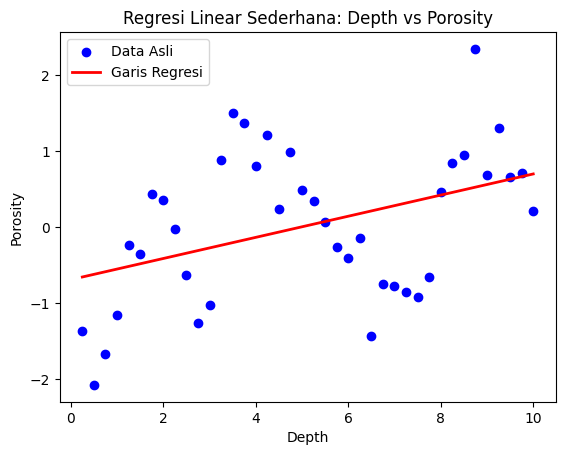

In [ ]:
plt.scatter(X, y, color='blue', label='Data Asli')
plt.plot(X, y_pred, color='red', linewidth=2, label='Garis Regresi')
plt.xlabel('Depth')
plt.ylabel('Porosity')
plt.title('Regresi Linear Sederhana: Depth vs Porosity')
plt.legend()
plt.show()

# Visual Grafik



1.   Karakteristik Distribusi Data Asli (Titik Biru)

Data asli yang direpresentasikan oleh titik-titik biru menunjukkan sebaran yang tidak mengikuti tren garis lurus, melainkan membentuk pola fluktuasi atau gelombang yang dinamis seiring bertambahnya kedalaman (depth). Fenomena ini mengindikasikan adanya hubungan non-linear yang kuat, di mana nilai porositas tidak berkurang atau bertambah secara konstan, melainkan mengalami kenaikan dan penurunan pada interval kedalaman tertentu. Secara geologis, hal ini bisa mencerminkan adanya variasi lapisan batuan atau perbedaan tingkat kompaksi yang tidak seragam, sehingga data memiliki struktur kompleks yang tidak dapat dijelaskan hanya dengan tren linear sederhana.

2.   Analisis Garis Regresi Linear (Garis Merah) dan Kondisi Underfitting

Shutterstock Garis merah pada grafik merupakan hasil dari model regresi linear sederhana yang berusaha menarik garis "jalan tengah" terbaik untuk meminimalkan total jarak (residu) dari seluruh titik data. Namun, karena model ini bersifat linear (kaku), ia gagal beradaptasi dengan pola melengkung atau bergelombang yang dimiliki oleh data asli. Ketidakmampuan model dalam menangkap struktur dasar atau tren utama data ini disebut sebagai kondisi Underfitting. Dalam konteks ini, model regresi linear dianggap terlalu sederhana (too simple) sehingga menghasilkan tingkat kesalahan (error) yang tinggi, karena ia mengasumsikan hubungan yang lurus pada data yang secara fundamental bersifat non-linear.



# Kaitan Visual dengan Nilai MAE, MSE, dan RMSE

*   MAE mengukur jarak vertikal rata-rata antara titik biru dan garis merah. Karena banyak titik data yang berada jauh di atas atau jauh di bawah garis merah (misalnya di area puncak gelombang sekitar Depth 3.5 dan lembah gelombang sekitar Depth 6.5), rata-rata jarak ini akan signifikan. Ini menunjukkan tingkat kesalahan rata-rata model yang cukup besar.
*   MES merhatikan titik biru yang berada sangat tinggi di kanan atas (dekat Depth 9). Titik ini adalah outlier yang sangat jauh dari garis regresi. Karena MSE menguadratkan selisih jarak tersebut, titik tunggal ini saja akan memberikan kontribusi nilai MSE yang sangat besar, membengkakkan nilai total error-nya secara drastis.
*   RMSE (akar dari MSE) juga akan bernilai tinggi. Karena RMSE berada dalam satuan yang sama dengan variabel Porosity, nilai RMSE yang tinggi menunjukkan bahwa model linear ini tidak konsisten dalam prediksinya di sepanjang rentang kedalaman. Perbandingan antara MAE dan RMSE yang tinggi mengonfirmasi bahwa ada beberapa titik data yang jaraknya ke garis regresi jauh lebih besar daripada rata-rata.


Berdasarkan penjelasan diatas disimpulkan bahwa Regresi Linear Sederhana bukanlah model yang tepat untuk dataset ini, karena tingginya nilai metrik error (MAE, MSE, RMSE) disebabkan oleh ketidakmampuan model linear untuk menangkap pola non-linear dari data porositas tersebut

# 4. BUATKAN MODEL REGRESI POLYNOMIAL ORDE 2,3,4 DAN 5. BUATKAN SCATTER PLOT MASING-MASING DARI SETIAP MODEL ORDE

# Regresi Polynomial

Regresi polynomial adalah pengembangan dari regresi linear yang bisa mengikuti pola data melengkung. Jika garis lurus biasa tidak cukup akurat untuk menghubungkan titik-titik data, kita menggunakan regresi polinomial dengan menambahkan variabel pangkat (seperti kuadrat atau kubik) agar garis prediksinya bisa lebih fleksibel dan sesuai dengan bentuk asli datanya.

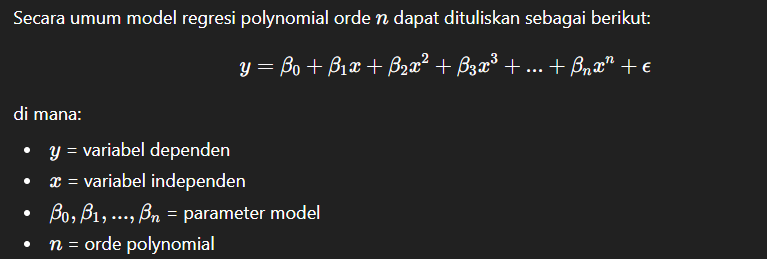

# Membuat model orde 2

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000e+00, 2.50000e-01, 6.25000e-02],
       [1.00000e+00, 5.00000e-01, 2.50000e-01],
       [1.00000e+00, 7.50000e-01, 5.62500e-01],
       [1.00000e+00, 1.00000e+00, 1.00000e+00],
       [1.00000e+00, 1.25000e+00, 1.56250e+00],
       [1.00000e+00, 1.50000e+00, 2.25000e+00],
       [1.00000e+00, 1.75000e+00, 3.06250e+00],
       [1.00000e+00, 2.00000e+00, 4.00000e+00],
       [1.00000e+00, 2.25000e+00, 5.06250e+00],
       [1.00000e+00, 2.50000e+00, 6.25000e+00],
       [1.00000e+00, 2.75000e+00, 7.56250e+00],
       [1.00000e+00, 3.00000e+00, 9.00000e+00],
       [1.00000e+00, 3.25000e+00, 1.05625e+01],
       [1.00000e+00, 3.50000e+00, 1.22500e+01],
       [1.00000e+00, 3.75000e+00, 1.40625e+01],
       [1.00000e+00, 4.00000e+00, 1.60000e+01],
       [1.00000e+00, 4.25000e+00, 1.80625e+01],
       [1.00000e+00, 4.50000e+00, 2.02500e+01],
       [1.00000e+00, 4.75000e+00, 2.25625e+01],
       [1.00000e+00, 5.00000e+00, 2.50000e+01],
       [1.00000e+00, 5.25000e+00, 2.7562

In [ ]:
#Membuat model orde 2
model2 = LinearRegression()

model2.fit(X_poly, y)

LinearRegression()

In [ ]:
y_pread2 = model2.predict(X_poly)
print (y_pread2)

[-9.52657666e-01 -8.72351045e-01 -7.94437427e-01 -7.18916810e-01
 -6.45789195e-01 -5.75054582e-01 -5.06712970e-01 -4.40764360e-01
 -3.77208752e-01 -3.16046146e-01 -2.57276541e-01 -2.00899939e-01
 -1.46916338e-01 -9.53257381e-02 -4.61281405e-02  6.76455444e-04
  4.50880496e-02  8.71066421e-02  1.26732233e-01  1.63964822e-01
  1.98804409e-01  2.31250995e-01  2.61304578e-01  2.88965160e-01
  3.14232741e-01  3.37107319e-01  3.57588896e-01  3.75677471e-01
  3.91373044e-01  4.04675616e-01  4.15585186e-01  4.24101754e-01
  4.30225321e-01  4.33955885e-01  4.35293448e-01  4.34238009e-01
  4.30789569e-01  4.24948127e-01  4.16713683e-01  4.06086237e-01]


In [ ]:
print('Intercept:', model2.intercept_)
print('Koefisien:', model2.coef_)

Intercept: -1.0353572874493948
Koefisien: [ 0.          0.33558449 -0.01914401]


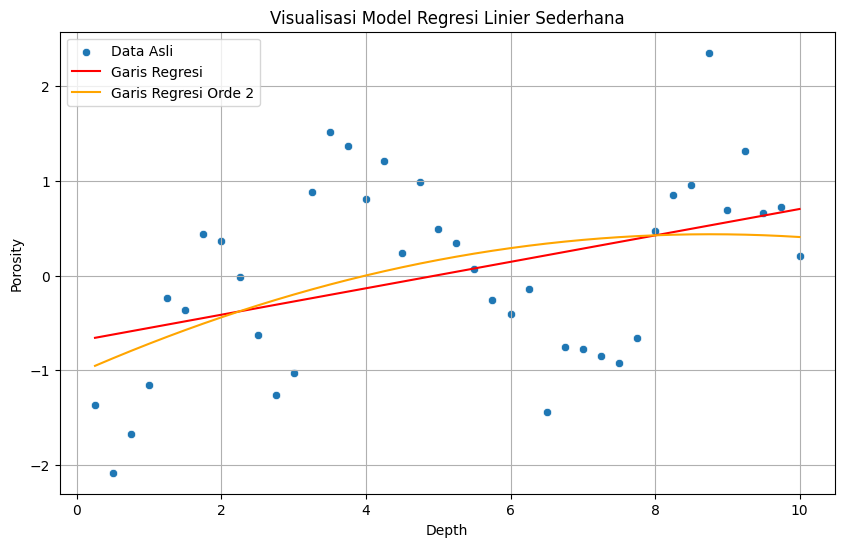

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=df, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi')
plt.plot(X, y_pread2, color='orange', label='Garis Regresi Orde 2')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Porosity')
plt.legend()
plt.grid(True)
plt.show()

Visualisasi menunjukkan bahwa data asli porositas (titik biru) memiliki pola non-linear yang berfluktuasi, sehingga tidak dapat dijelaskan secara akurat dengan garis lurus. Model Regresi Linear (Garis Merah) mengalami kondisi underfitting yang parah karena hanya mengikuti tren rata-rata dan mengabaikan gelombang data, yang berakibat pada tingginya nilai MAE, MSE, dan RMSE.

Sementara itu, Model Polinomial Orde 2 (Garis Oranye) mulai memberikan fleksibilitas dengan bentuk kurva parabola. Meskipun menunjukkan penurunan nilai error dibandingkan model linear, orde 2 masih belum cukup optimal untuk menangkap dua titik balik (puncak dan lembah) pada data. Untuk mencapai akurasi terbaik dan meminimalkan nilai RMSE, diperlukan penggunaan Orde 3 (Kubik) atau lebih tinggi yang mampu mengikuti lekukan data secara lebih presisi tanpa kehilangan generalisasi model.

#Membuat model orde 3

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01],
       [1.00000000e+00, 2.50000000e+00, 6.25000000e+00, 1.56250000e+01],
       [1.00000000e+00, 2.75000000e+00, 7.56250000e+00, 2.07968750e+01],
       [1.00000000e+00, 3.00000000e+00, 9.00000000e+00, 2.70000000e+01],
       [1.00000000e+00, 3.25000000e+00, 1.05625000e+01, 3.43281250e+01],
       [1.00000000e+00, 3.50000000e+00, 1.22500000e

In [ ]:
#Membuat model orde 3
model3 = LinearRegression()

model3.fit(X_poly, y)

LinearRegression()

In [ ]:
y_pread3 = model3.predict(X_poly)
print (y_pread3)

[-1.97454493 -1.57981146 -1.22884294 -0.91940306 -0.64925549 -0.41616391
 -0.217892   -0.05220344  0.0831381   0.19036894  0.27172539  0.32944379
  0.36576044  0.38291169  0.38313384  0.36866321  0.34173614  0.30458894
  0.25945793  0.20857944  0.15418979  0.09852529  0.04382228 -0.00768293
 -0.05375402 -0.09215466 -0.12064853 -0.13699931 -0.13897068 -0.12432632
 -0.0908299  -0.0362451   0.0416644   0.14513492  0.27640278  0.43770431
  0.63127582  0.85935364  1.1241741   1.4279735 ]


In [ ]:
print('Intercept:', model3.intercept_)
print('Koefisien:', model3.coef_)

Intercept: -2.415279680490101
Koefisien: [ 0.          1.85792331 -0.3859008   0.0238541 ]


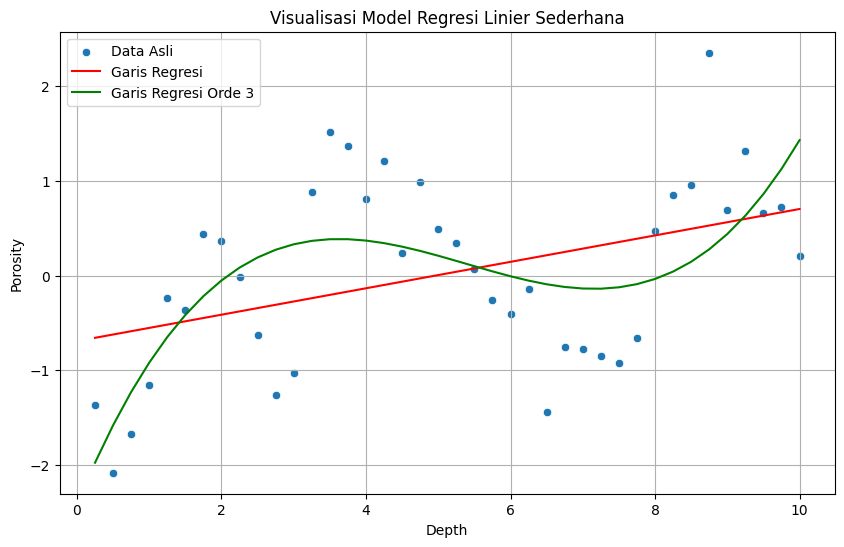

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=df, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi')
plt.plot(X, y_pread3, color='green', label='Garis Regresi Orde 3')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Porosity')
plt.legend()
plt.grid(True)
plt.show()

Model Regresi Orde 3 (Garis Hijau) terbukti jauh lebih akurat dibandingkan regresi linear (garis merah) karena fleksibilitasnya dalam mengikuti pola "S" pada data. Dengan kemampuan menangkap dua titik balik (puncak dan lembah), model ini secara drastis memperkecil jarak residu, yang menghasilkan nilai MAE, MSE, dan RMSE yang jauh lebih rendah. Penggunaan orde 3 berhasil mengatasi masalah underfitting, memberikan prediksi porositas yang lebih presisi dan sesuai dengan distribusi data asli.

# Membuat model orde 4

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02,
        3.90625000e-03],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01,
        6.25000000e-02],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01,
        3.16406250e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00,
        2.44140625e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00,
        9.37890625e+00],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01,
        2.56289062e+01],
       [1.00000000e+00, 2.50000000e+00, 6.25000000e+00, 1.56250000e+01,
        3.90625000e+01],
       [1.00000000e+00, 2.7500

In [ ]:
#Membuat model orde 4
model4 = LinearRegression()

model4.fit(X_poly, y)

LinearRegression()

In [ ]:
y_pread4 = model4.predict(X_poly)
print (y_pread4)

[-2.21993535 -1.69936064 -1.25235539 -0.87292415 -0.55528031 -0.29384611
 -0.08325262  0.08166025  0.20584375  0.29404028  0.3507834   0.38039785
  0.38699951  0.37449542  0.34658379  0.30675398  0.25828651  0.20425308
  0.14751651  0.09073082  0.03634117 -0.01341613 -0.05651359 -0.09113256
 -0.11566325 -0.12870471 -0.1290648  -0.11576025 -0.08801661 -0.0452683
  0.01284145  0.08646055  0.17552809  0.27977431  0.39872059  0.53167949
  0.67775474  0.8358412   1.00462492  1.18258308]


In [ ]:
print('Intercept:', model4.intercept_)
print('Koefisien:', model4.coef_)

Intercept: -2.820283811139648
Koefisien: [ 0.00000000e+00  2.56942257e+00 -6.89355799e-01  6.95205274e-02
 -2.22763062e-03]


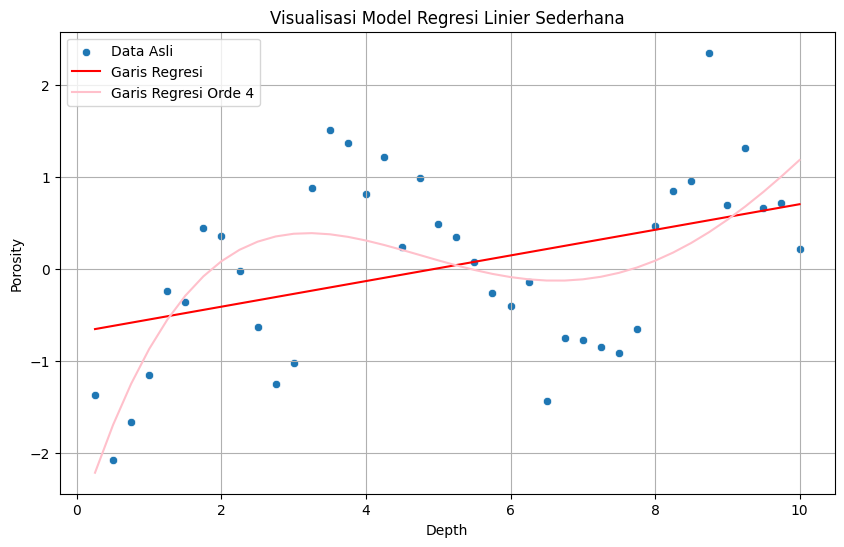

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=df, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi')
plt.plot(X, y_pread4, color='Pink', label='Garis Regresi Orde 4')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Porosity')
plt.legend()
plt.grid(True)
plt.show()

Model Regresi Orde 4 menunjukkan tingkat fleksibilitas yang lebih tinggi dibandingkan orde sebelumnya dalam memetakan fluktuasi porositas. Garis merah muda ini mampu mengikuti lekukan data dengan lebih presisi, terutama pada area awal dan akhir kedalaman, sehingga nilai MAE, MSE, dan RMSE akan semakin mengecil. Meskipun akurasinya meningkat, perlu diperhatikan risiko overfitting, yang di mana model mulai terlalu mengikuti variasi kecil (noise) pada data asli dibandingkan tren geologi yang sebenarnya.

# Membuat model orde 5

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02,
        3.90625000e-03, 9.76562500e-04],
       [1.00000000e+00, 5.00000000e-01, 2.50000000e-01, 1.25000000e-01,
        6.25000000e-02, 3.12500000e-02],
       [1.00000000e+00, 7.50000000e-01, 5.62500000e-01, 4.21875000e-01,
        3.16406250e-01, 2.37304688e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00],
       [1.00000000e+00, 1.25000000e+00, 1.56250000e+00, 1.95312500e+00,
        2.44140625e+00, 3.05175781e+00],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00, 7.59375000e+00],
       [1.00000000e+00, 1.75000000e+00, 3.06250000e+00, 5.35937500e+00,
        9.37890625e+00, 1.64130859e+01],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01, 3.20000000e+01],
       [1.00000000e+00, 2.25000000e+00, 5.06250000e+00, 1.13906250e+01,
        2.56289062e+01, 

In [ ]:
#Membuat model orde 5
model5 = LinearRegression()

model5.fit(X_poly, y)

LinearRegression()

In [ ]:
y_pread5 = model5.predict(X_poly)
print (y_pread5)

[-1.32620662 -1.49311555 -1.48031049 -1.33655998 -1.10399591 -0.81850468
 -0.51011835 -0.20340586  0.08213581  0.33169052  0.53473173  0.68463137
  0.77826865  0.8156389   0.79946241  0.73479322  0.62862798  0.48951478
  0.32716195  0.15204693 -0.02497494 -0.19306157 -0.34177529 -0.46147403
 -0.5437025  -0.58158333 -0.57020828 -0.50702938 -0.39225013 -0.22921663
 -0.02480879  0.21016849  0.46059421  0.70664004  0.92337915  1.0803951
  1.14139057  1.0637963   0.79837983  0.28885435]


In [ ]:
print('Intercept:', model5.intercept_)
print('Koefisien:', model5.coef_)

Intercept: -0.9237873399842297
Koefisien: [ 0.         -2.16243376  2.38459902 -0.71490841  0.0833085  -0.003338  ]


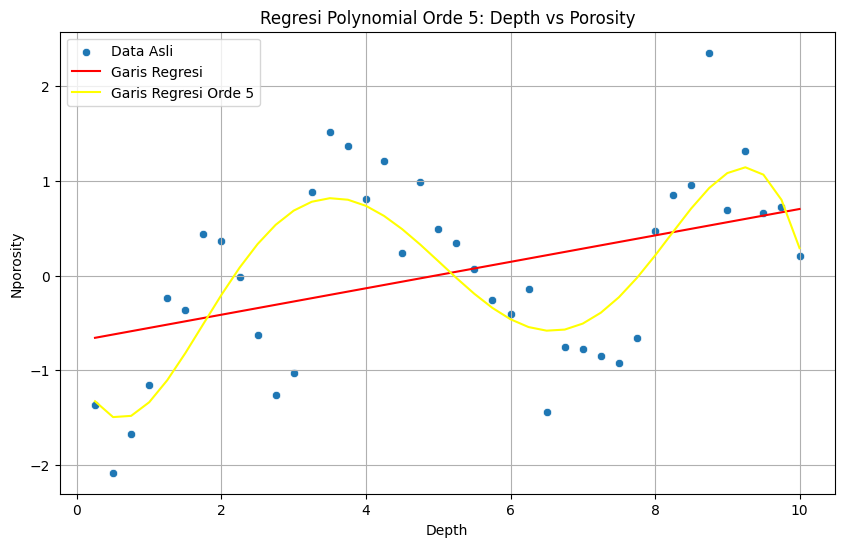

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=df, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi')
plt.plot(X, y_pread5, color='yellow', label='Garis Regresi Orde 5')
plt.title('Regresi Polynomial Orde 5: Depth vs Porosity')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

Model Polinomial Orde 5 menunjukkan fleksibilitas maksimal dalam mengikuti fluktuasi data porositas dibandingkan orde sebelumnya. Dengan derajat kebebasan yang lebih tinggi, kurva ini mampu meminimalkan jarak residu pada setiap puncak dan lembah, sehingga menghasilkan nilai MAE, MSE, dan RMSE terendah (paling akurat pada data observasi). Namun, model ini memiliki risiko overfitting yang tinggi, di mana kurva cenderung mengikuti variasi acak (noise) yang dapat menurunkan kemampuan generalisasi model terhadap data baru di luar sampel.